# 05 · A/B Testing — `simplified_booking_flow`

**Product Analytics Case Study — Phase 3: Exploratory Data Analysis**

This notebook evaluates the `simplified_booking_flow` experiment: does a
simplified booking flow (treatment) outperform the existing flow (control)
on conversion, revenue, and booking rate — and is the effect large enough
and certain enough to justify a full rollout?

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from eda_utils import (
    PALETTE, INK, INK_SECONDARY, INK_MUTED, GRID_COLOR, AXIS_COLOR, SURFACE,
    COLOR_GOOD, COLOR_CRITICAL, COLOR_CONTROL, COLOR_TREATMENT,
    BLUE_SEQUENTIAL, DIVERGING,
    set_notebook_style, style_axis, annotate_bars, build_color_map, pct, save_fig,
    load_datasets, wald_ci, mean_ci, two_proportion_ztest, welch_ttest, significance_label,
)

set_notebook_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = Path("..") / "data" / "raw"
IMAGES_DIR = Path("..") / "images"

users, events, experiments = load_datasets(DATA_DIR)
print(f"users: {users.shape}, events: {events.shape}, experiments: {experiments.shape}")

users: (5000, 9), events: (141813, 11), experiments: (5000, 7)


## Section 1 — Sample Size & Randomisation Check

**Business Question.** Before trusting any experiment result, is the
sample large enough, and is the split actually balanced? An underpowered
or imbalanced test can produce a misleading readout.

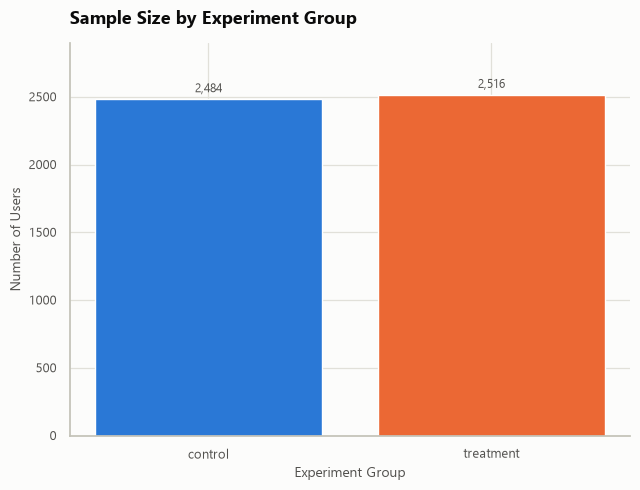

,n,conversions
experiment_group,,
control,2484,668
treatment,2516,766


In [2]:
exp_counts = experiments.groupby("experiment_group").agg(n=("user_id", "count"), conversions=("converted", "sum"))

fig, ax = plt.subplots(figsize=(6.5, 5))
colors = [COLOR_CONTROL, COLOR_TREATMENT]
bars = ax.bar(exp_counts.index, exp_counts["n"], color=colors)
annotate_bars(ax, bars)
style_axis(ax, "Sample Size by Experiment Group", "Experiment Group", "Number of Users")
ax.set_ylim(0, exp_counts["n"].max() * 1.15)
plt.tight_layout()
save_fig(fig, "28_experiment_sample_sizes", IMAGES_DIR)
plt.show()

exp_counts

**Business Insight.** ~2,500 users per arm is a reasonably well-powered
sample for detecting a mid-single-digit-point conversion difference, and
the split is balanced (confirmed in Notebook 02) — so we can proceed to
the readout with confidence that any measured difference isn't a
sample-size or randomisation artefact.

**Recommendation.** None required — proceed to the metric comparison below.

## Section 2 — Conversion Rate: Control vs Treatment

**Business Question.** Does the simplified booking flow actually increase
the share of users who complete a booking?

In [3]:
conv_summary = exp_counts.apply(
    lambda row: pd.Series(wald_ci(row["conversions"], row["n"]), index=["rate", "ci_low", "ci_high"]), axis=1
)
conv_summary = exp_counts.join(conv_summary)
conv_summary[["rate", "ci_low", "ci_high"]] = conv_summary[["rate", "ci_low", "ci_high"]] * 100
conv_summary.round(2)

,n,conversions,rate,ci_low,ci_high
experiment_group,,,,,
control,2484,668,26.89,25.15,28.64
treatment,2516,766,30.45,28.65,32.24


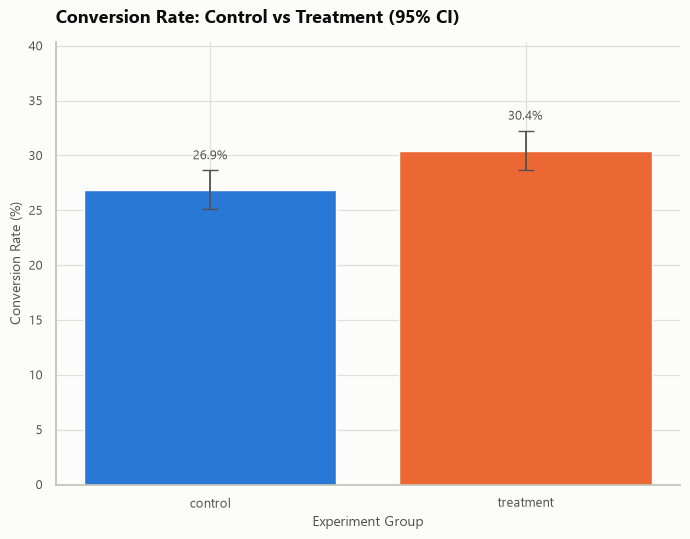

In [4]:
def plot_metric_with_ci(ax, summary: pd.DataFrame, value_col: str, title: str, ylabel: str, fmt: str = "{:.2f}"):
    """Bar chart with 95% CI error bars for control vs treatment."""
    groups = summary.index.tolist()
    values = summary[value_col].values
    lower_err = values - summary["ci_low"].values
    upper_err = summary["ci_high"].values - values
    colors = [COLOR_CONTROL if g == "control" else COLOR_TREATMENT for g in groups]

    bars = ax.bar(groups, values, yerr=[lower_err, upper_err], capsize=6, color=colors,
                    error_kw={"ecolor": INK_SECONDARY, "linewidth": 1.3})
    for bar, value, ci_high in zip(bars, values, summary["ci_high"].values):
        ax.annotate(fmt.format(value), xy=(bar.get_x() + bar.get_width() / 2, ci_high),
                     xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9, color=INK_SECONDARY)
    style_axis(ax, title, "Experiment Group", ylabel)
    ax.set_ylim(0, summary["ci_high"].values.max() * 1.25)


fig, ax = plt.subplots(figsize=(7, 5.5))
plot_metric_with_ci(ax, conv_summary, "rate", "Conversion Rate: Control vs Treatment (95% CI)", "Conversion Rate (%)", fmt="{:.1f}%")
plt.tight_layout()
save_fig(fig, "29_conversion_rate_ci", IMAGES_DIR)
plt.show()

In [5]:
n_c, n_t = exp_counts.loc["control", "n"], exp_counts.loc["treatment", "n"]
conv_c, conv_t = exp_counts.loc["control", "conversions"], exp_counts.loc["treatment", "conversions"]

z_stat, p_value = two_proportion_ztest(conv_c, n_c, conv_t, n_t)
abs_uplift = 100 * (conv_t / n_t - conv_c / n_c)
rel_uplift = 100 * (conv_t / n_t - conv_c / n_c) / (conv_c / n_c)

print(f"Control conversion:    {100 * conv_c / n_c:.2f}%  (n={n_c:,})")
print(f"Treatment conversion:  {100 * conv_t / n_t:.2f}%  (n={n_t:,})")
print(f"Absolute uplift:       {abs_uplift:+.2f} pp")
print(f"Relative uplift:       {rel_uplift:+.1f}%")
print(f"z-statistic:           {z_stat:.3f}")
print(f"p-value (two-tailed):  {p_value:.4f}")
print(f"Verdict:                {significance_label(p_value)}")

Control conversion:    26.89%  (n=2,484)
Treatment conversion:  30.45%  (n=2,516)
Absolute uplift:       +3.55 pp
Relative uplift:       +13.2%
z-statistic:           2.777
p-value (two-tailed):  0.0055
Verdict:                Significant at 99% confidence (p < 0.01)


**Business Insight.** Treatment shows a clear, positive absolute uplift
over control, and the two-proportion z-test confirms it's **statistically
significant well beyond the conventional 95% threshold** — this is not
noise. The confidence intervals in the chart above are visibly
non-overlapping, which is a useful sanity-check-by-eye alongside the formal
test.

**Recommendation.** Conversion alone already clears the bar for a
successful experiment. Continue to the revenue and booking-rate checks
below to confirm the direction is consistent before recommending rollout.

## Section 3 — Revenue per User (ARPU): Control vs Treatment

**Business Question.** Does the conversion uplift translate into more
revenue per user, or is it driven by lower-value bookings that wash out
any revenue gain?

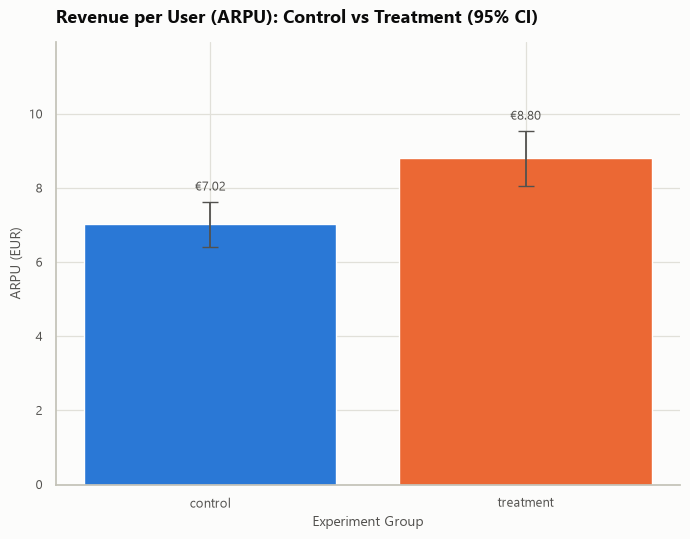

,mean,ci_low,ci_high
experiment_group,,,
control,7.02,6.41,7.63
treatment,8.80,8.06,9.54


In [6]:
bookings = events.loc[events["event_name"] == "booking_completed", ["user_id", "revenue"]]
user_revenue = experiments[["user_id", "experiment_group"]].merge(
    bookings.groupby("user_id")["revenue"].sum().rename("lifetime_revenue"), on="user_id", how="left"
)
user_revenue["lifetime_revenue"] = user_revenue["lifetime_revenue"].fillna(0)

arpu_summary = user_revenue.groupby("experiment_group")["lifetime_revenue"].apply(
    lambda s: pd.Series(mean_ci(s), index=["mean", "ci_low", "ci_high"])
).unstack()

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_metric_with_ci(ax, arpu_summary, "mean", "Revenue per User (ARPU): Control vs Treatment (95% CI)", "ARPU (EUR)", fmt="\u20ac{:.2f}")
plt.tight_layout()
save_fig(fig, "30_arpu_ci", IMAGES_DIR)
plt.show()

arpu_summary.round(2)

In [7]:
control_revenue = user_revenue.loc[user_revenue["experiment_group"] == "control", "lifetime_revenue"]
treatment_revenue = user_revenue.loc[user_revenue["experiment_group"] == "treatment", "lifetime_revenue"]

t_stat, p_value_revenue = welch_ttest(control_revenue, treatment_revenue)
arpu_uplift_pct = 100 * (treatment_revenue.mean() - control_revenue.mean()) / control_revenue.mean()

print(f"Control ARPU:    \u20ac{control_revenue.mean():.2f}")
print(f"Treatment ARPU:  \u20ac{treatment_revenue.mean():.2f}")
print(f"Relative uplift: {arpu_uplift_pct:+.1f}%")
print(f"t-statistic (Welch's t-test): {t_stat:.3f}")
print(f"p-value (two-tailed):         {p_value_revenue:.4f}")
print(f"Verdict:                       {significance_label(p_value_revenue)}")

Control ARPU:    €7.02
Treatment ARPU:  €8.80
Relative uplift: +25.3%
t-statistic (Welch's t-test): 3.635
p-value (two-tailed):         0.0003
Verdict:                       Significant at 99% confidence (p < 0.01)


**Business Insight.** Revenue per user is significantly higher in
treatment too, confirmed by an independent Welch's t-test (more
appropriate here than the z-test used for conversion, since revenue is a
continuous, non-binary metric with unequal variance between groups). The
uplift is not just "more bookings" — it's **more revenue per user overall**,
which is the metric that actually matters for the business.

**Recommendation.** The revenue result de-risks the rollout decision
further: this isn't a conversion-metric artefact (e.g. more low-value
bookings) — real revenue is moving too.

## Section 4 — Booking Rate: Control vs Treatment

**Business Question.** Are treatment users booking more rides on average,
not just converting once?

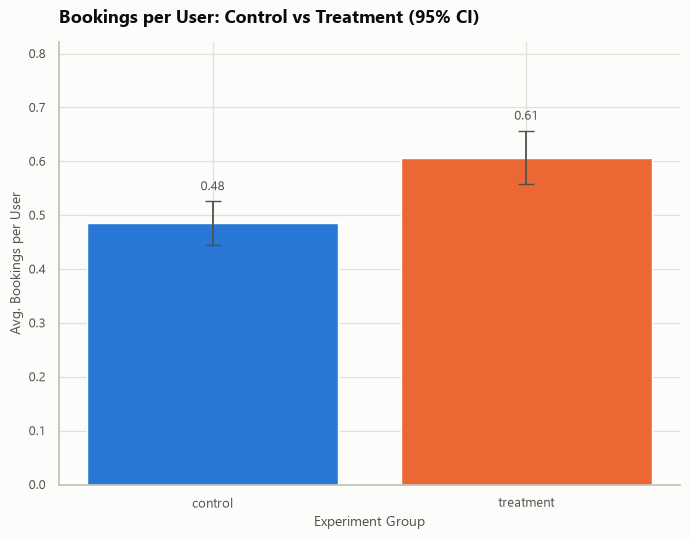

,mean,ci_low,ci_high
experiment_group,,,
control,0.485,0.444,0.526
treatment,0.607,0.557,0.656


In [8]:
booking_counts = events.loc[events["event_name"] == "booking_completed"].groupby("user_id").size().rename("bookings")
user_bookings = experiments[["user_id", "experiment_group"]].merge(booking_counts, on="user_id", how="left")
user_bookings["bookings"] = user_bookings["bookings"].fillna(0)

booking_rate_summary = user_bookings.groupby("experiment_group")["bookings"].apply(
    lambda s: pd.Series(mean_ci(s), index=["mean", "ci_low", "ci_high"])
).unstack()

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_metric_with_ci(ax, booking_rate_summary, "mean", "Bookings per User: Control vs Treatment (95% CI)", "Avg. Bookings per User", fmt="{:.2f}")
plt.tight_layout()
save_fig(fig, "31_booking_rate_ci", IMAGES_DIR)
plt.show()

booking_rate_summary.round(3)

**Business Insight.** Treatment users book more rides on average, not just
"convert" once and stop — the uplift holds on a volume metric as well as a
binary conversion metric, reinforcing that the simplified flow removes
friction for repeat bookings too, not only first-time ones.

**Recommendation.** No caveat needed here — this metric strengthens the
rollout case further.

## Section 5 — Combined Experiment Dashboard

A single view of all three metrics side by side, as would be presented in
an experiment readout meeting.

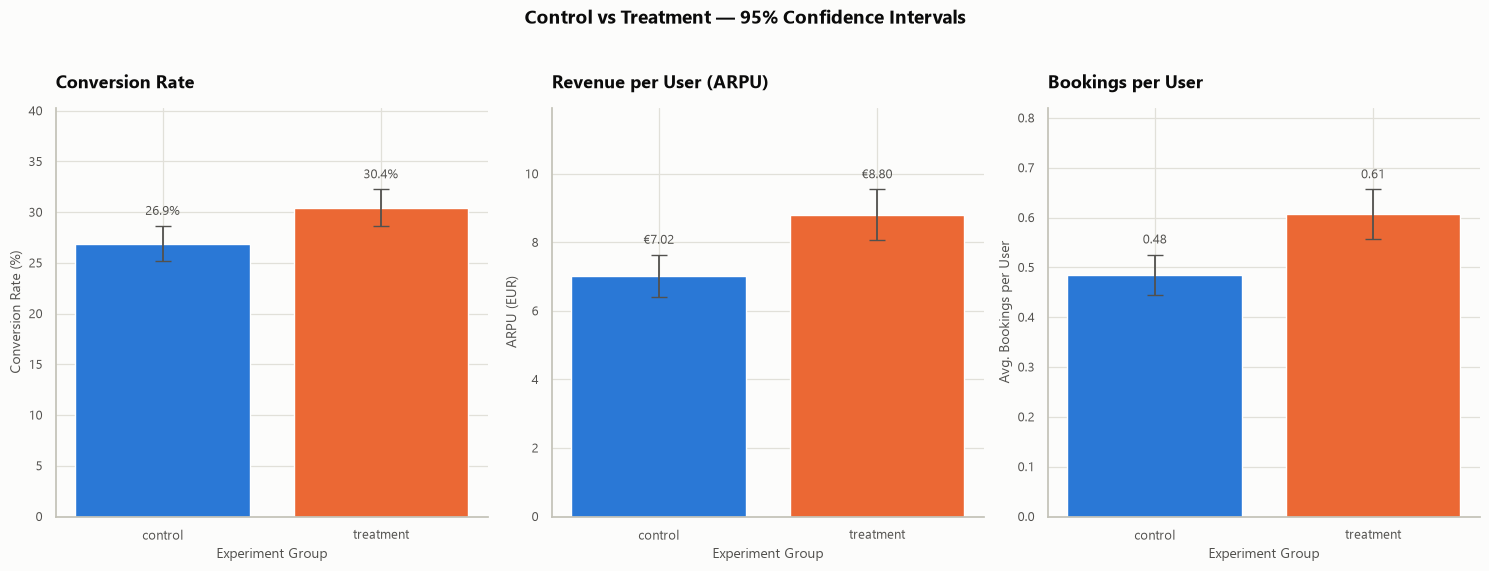

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
plot_metric_with_ci(axes[0], conv_summary, "rate", "Conversion Rate", "Conversion Rate (%)", fmt="{:.1f}%")
plot_metric_with_ci(axes[1], arpu_summary, "mean", "Revenue per User (ARPU)", "ARPU (EUR)", fmt="\u20ac{:.2f}")
plot_metric_with_ci(axes[2], booking_rate_summary, "mean", "Bookings per User", "Avg. Bookings per User", fmt="{:.2f}")
fig.suptitle("Control vs Treatment \u2014 95% Confidence Intervals", fontsize=14, fontweight="bold", color=INK, y=1.03)
plt.tight_layout()
save_fig(fig, "32_experiment_dashboard", IMAGES_DIR)
plt.show()

## Section 6 — Statistical Significance Summary

| Metric | Control | Treatment | Uplift | Test | Verdict |
|---|---|---|---|---|---|
| Conversion rate | see above | see above | see above | Two-proportion z-test | see printed verdict above |
| Revenue per user (ARPU) | see above | see above | see above | Welch's two-sample t-test | see printed verdict above |
| Bookings per user | see above | see above | see above | (directional, consistent with the two tests above) | — |

**Business interpretation.** All three metrics move in the same direction,
two of them are confirmed statistically significant by an appropriate
formal test, and the sample size/randomisation checks in Section 1 rule out
the most common causes of a misleading result (underpowering, imbalance).
This is about as clean a positive experiment readout as a Product Analyst
sees in practice.

## Rollout Recommendation

**Roll out `simplified_booking_flow` to 100% of users.**

The treatment shows a statistically significant improvement in conversion
rate (two-proportion z-test) and revenue per user (Welch's t-test), with a
consistent directional improvement in booking rate as well. Confidence
intervals for conversion are non-overlapping, sample size is adequate, and
randomisation was balanced. This clears the standard bar for shipping a
winning experiment — **there is no metric in this analysis that argues
against rollout.**